# Finding the Second- and Third-Order Winners of EU Tariffs on AliExpress-Style Parcels

### A derivative-exposure screen of European mid- and large-caps

When Europe taxes low-value parcels from platforms such as AliExpress, Temu, and Shein, the obvious names move first: listed European retailers that compete with those platforms, and logistics groups that handle inbound China–EU parcels. Those are **first derivative** exposures, and they are already in every trade-policy note.

The harder question is what happens *next*. Marketplaces and posts raise handling fees. Brands reclaim shelf space as ultra-cheap imports lose their de-minimis edge. Advertising, payments, and shopping-centre traffic re-route toward European merchants. These **second** and **third derivative** exposures sit in companies that no “China e-commerce tariff” screen would ever surface — and that is exactly where the unpriced opportunity tends to live.

This notebook builds that map automatically and tests it against real disclosure. It:

1. **Grounds** the theme in current market evidence from [Bigdata.com](https://bigdata.com)
2. **Builds a mindmap** of exposure pathways, organised into three derivative hops
3. **Searches** filings, earnings calls, and premium news for each pathway across the portfolio
4. **Classifies** every retrieved quote and attributes it to a company and a pathway
5. **Summarises** each exposed company and exports the evidence pack

Every conclusion below traces back to a dated, attributable quote from a primary document.

## Environment

The pipeline logic lives in the `src` package; this notebook only orchestrates and presents it. Two credentials are read from the project `.env` file: `BIGDATA_API_KEY` for evidence retrieval and `OPENAI_API_KEY` for taxonomy generation and classification.

The cell below also switches the working directory to the project root so relative paths resolve the same way they do for the command-line tool.

In [1]:
from __future__ import annotations

import json
import os
import textwrap
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
os.chdir(PROJECT_ROOT)
load_dotenv(PROJECT_ROOT / ".env")

from src import screener, viz
from src.derivative_grounding import collect_grounding, format_grounding_brief, write_grounding
from src.derivative_taxonomy import derivative_preview, validate_derivatives_taxonomy
from src.modes import AnalysisMode, get_profile
from src.notebook_support import preview_quote, quiet_output
from src.prompts import DERIVATIVE_BRANCH_LABELS, TAXONOMY_STYLE_DERIVATIVES
from src.run_context import RunContext

pd.set_option("display.max_colwidth", 110)
%matplotlib inline

print(f"Project root: {PROJECT_ROOT}")
print(f"Bigdata.com credentials loaded: {bool(os.getenv('BIGDATA_API_KEY'))}")
print(f"OpenAI credentials loaded:      {bool(os.getenv('OPENAI_API_KEY'))}")

Project root: /Users/franciscogomez/git/bigdata/bigdata-cookbook/Thematic_Screener_CLI
Bigdata.com credentials loaded: True
OpenAI credentials loaded:      True


## Defining the screen

Four inputs define the analysis:

| Input | Purpose |
|---|---|
| **Theme** | The shock whose consequences we trace outward |
| **Analyst focus** | Steers the mindmap toward hidden, indirect exposures rather than the obvious listed retailers competing with Temu and AliExpress |
| **Universe** | European mid- and large-caps (`europe_ml_caps.csv`) — the portfolio we are screening |
| **Window** | The publication period searched for evidence |

`RETRIEVAL_DEPTH` sets how deeply each pathway samples its available evidence pool. This universe is several times larger than a typical 150-name book, so 10% is the working depth for this pass.

Every artefact is written to an isolated run directory, so this analysis can be reproduced, audited, or resumed from the command line later.

In [2]:
MAIN_THEME = "EU tariffs on low-value Chinese e-commerce parcels"
ANALYST_FOCUS = (
    "Hidden 1st/2nd/3rd derivative exposures in European mid and large caps: "
    "direct price competition and import-cost shock versus AliExpress, Temu, and Shein; "
    "second-hop customs, logistics surcharges, and marketplace mix-shift; "
    "third-hop advertising, payments, mall traffic, and brands that never sold a low-value China parcel."
)
UNIVERSE_PATH = PROJECT_ROOT / "europe_ml_caps.csv"
START_DATE = "2025-06-01"
END_DATE = "2026-06-09"
RETRIEVAL_DEPTH = 0.1

RUN_NAME = "eu_parcel_tariff_derivatives"
MODE = AnalysisMode.THEMATIC_SCREENER.value
profile = get_profile(MODE)

context = RunContext.create(PROJECT_ROOT / "runs", RUN_NAME)
context.ensure_run_dir()
context.save_config(
    {
        "mode": MODE,
        "main_theme": MAIN_THEME,
        "analyst_focus": ANALYST_FOCUS,
        "universe": str(UNIVERSE_PATH),
        "start_date": START_DATE,
        "end_date": END_DATE,
        "taxonomy_style": TAXONOMY_STYLE_DERIVATIVES,
        "chunk_percentage": RETRIEVAL_DEPTH,
    }
)

print(f"Theme:  {MAIN_THEME}")
print(f"Window: {START_DATE} to {END_DATE}")
print(f"Run directory: {context.run_dir}")


Theme:  EU tariffs on low-value Chinese e-commerce parcels
Window: 2025-06-01 to 2026-06-09
Run directory: /Users/franciscogomez/git/bigdata/bigdata-cookbook/Thematic_Screener_CLI/runs/eu_parcel_tariff_derivatives


## The portfolio under review

The universe is the screening perimeter: every claim in this report is about one of these companies. Each row pairs a company name with the entity identifier used to attribute retrieved documents, which is what allows a quote buried in a filing to be tied back to a specific holding.

In [3]:
universe_df = screener.load_universe(UNIVERSE_PATH)
company_ids = universe_df[screener.UNIVERSE_ID_COLUMN].tolist()

print(f"{len(universe_df)} companies in the screening universe\n")
universe_df.head(8)

646 companies in the screening universe



,RP_ENTITY_ID,COMPANY_NAME
0,B0BB37,Dottikon Es Holding AG
1,B115EF,Societe Generale S.A.
2,B16C61,Beazley PLC
3,B17747,Technip Energies N.V.
4,B1A8A2,Bechtle AG
5,B2AA0A,Erste Group Bank AG
6,B2CDCE,Avolta AG
7,B2D445,Addtech AB


## Step 1 — Ground the theme in market evidence

Before proposing any exposure pathway, we ask the market what is actually happening. Three searches run against [Bigdata.com](https://bigdata.com), one per derivative hop:

- **First hop** — how EU parcel duties and the end of de-minimis treatment change landed cost and price competition with AliExpress-style platforms
- **Second hop** — how companies *respond*: customs processes, surcharge recovery, assortment mix, marketplace take-rates
- **Third hop** — knock-on shifts in advertising, payments, mall traffic, and brands that never imported a Temu parcel

These searches deliberately run **without a universe filter**. We want to learn the shape of the transmission chain from the global corpus of filings, transcripts, and premium news, not just from what our European holdings happen to have said. The resulting briefing is fed into the mindmap step so the taxonomy reflects observed behaviour rather than textbook theory.

In [4]:
with quiet_output():
    grounding = collect_grounding(
        MAIN_THEME,
        start_date=START_DATE,
        end_date=END_DATE,
        max_chunks_per_hop=8,
    )
write_grounding(context.grounding_path, grounding)
grounding_brief = format_grounding_brief(grounding)

for hop in grounding["hops"]:
    print(f"{hop['branch']}: {len(hop['chunks'])} supporting passages")

1st derivative: 8 supporting passages
2nd derivative: 8 supporting passages
3rd derivative: 5 supporting passages


### What the market is saying

The table below lists the sourced passages behind each hop. Note the mix of document types: filings describing customs and import costs, earnings calls where retailers discuss Chinese platform competition, and news coverage of parcel-duty reform. This is the raw material the mindmap is built from.

Source text is shown as a short lead-in only; the full passages are written to the run directory as `grounding.json`.

In [5]:
grounding_rows = [
    {
        "hop": hop["branch"],
        "source": chunk["source_name"],
        "date": str(chunk["timestamp"])[:10],
        "passage": preview_quote(chunk["text"]),
    }
    for hop in grounding["hops"]
    for chunk in hop["chunks"][:3]
]
pd.DataFrame(grounding_rows)

,hop,source,date,passage
0,1st derivative,Financial Times,2025-10-10,European governments are moving to levy national handling fees on small packages ordered online …
1,1st derivative,Financial Times,2025-12-14,"Brussels has asked for additional information from the company, which could lead to an …"
2,1st derivative,Alliance News,2026-03-26,(Alliance News) - EU states and lawmakers struck a deal Thursday to give the …
3,2nd derivative,Financial Times,2025-12-14,"Brussels has asked for additional information from the company, which could lead to an …"
4,2nd derivative,Financial Times,2025-10-10,European governments are moving to levy national handling fees on small packages ordered online …
5,2nd derivative,MT Newswires - Asia Pacific,2025-11-13,"The move could affect online traders such as Shein, Temu, and Alibaba (HKG:9988), according …"
6,3rd derivative,Financial Times,2025-10-10,European governments are moving to levy national handling fees on small packages ordered online …
7,3rd derivative,Benzinga,2025-10-30,"Tightening regulation The US has removed ""de minimis"" exemptions for low-value postal consignments after …"
8,3rd derivative,Quartr Transcripts,2025-07-29,And a little bit of flat growth in the EU. A lot of this …


## Step 2 — Build the derivative mindmap

The grounded briefing is now turned into a structured taxonomy: one root theme, three derivative branches, and a set of concrete **exposure pathways** beneath each.

A pathway is not a sector label — it is a specific economic mechanism by which a company gains or loses from the theme. "Airline capacity discipline" is a pathway; "transportation" is not. Each pathway also carries its own retrieval query, written in the voice of a disclosure document so it matches how companies actually describe themselves in filings and on calls.

The validation step confirms the tree has the required three-hop shape and that second- and third-hop queries are genuinely distinct from first-hop ones, rather than restating the original shock.

In [6]:
with quiet_output():
    root = screener.generate_taxonomy(
        main_theme=MAIN_THEME,
        analyst_focus=ANALYST_FOCUS,
        profile=profile,
        taxonomy_style=TAXONOMY_STYLE_DERIVATIVES,
        grounding_brief=grounding_brief,
        print_taxonomy=False,
    )

labels, search_queries = screener.write_taxonomy_artifacts(
    root,
    themes_path=context.themes_path,
    search_queries_path=context.search_queries_path,
    taxonomy_tree_path=context.taxonomy_tree_path,
    profile=profile,
)
findings = validate_derivatives_taxonomy(root)
preview = derivative_preview(root)

for branch, branch_leaves in preview.items():
    print(f"{branch}: {len(branch_leaves)} pathways")
print(f"\nTotal exposure pathways: {len(labels)}")
print(f"Structural validation: {'passed' if not findings else findings}")

1st derivative: 4 pathways
2nd derivative: 4 pathways
3rd derivative: 4 pathways

Total exposure pathways: 12
Structural validation: passed


### The exposure map

Read this left to right: the theme fans out into three hops, each hop into its pathways. Distance from the root is distance from the obvious trade. The first-hop names are the consensus view; the third-hop pathways on the right are where a screen like this earns its keep.

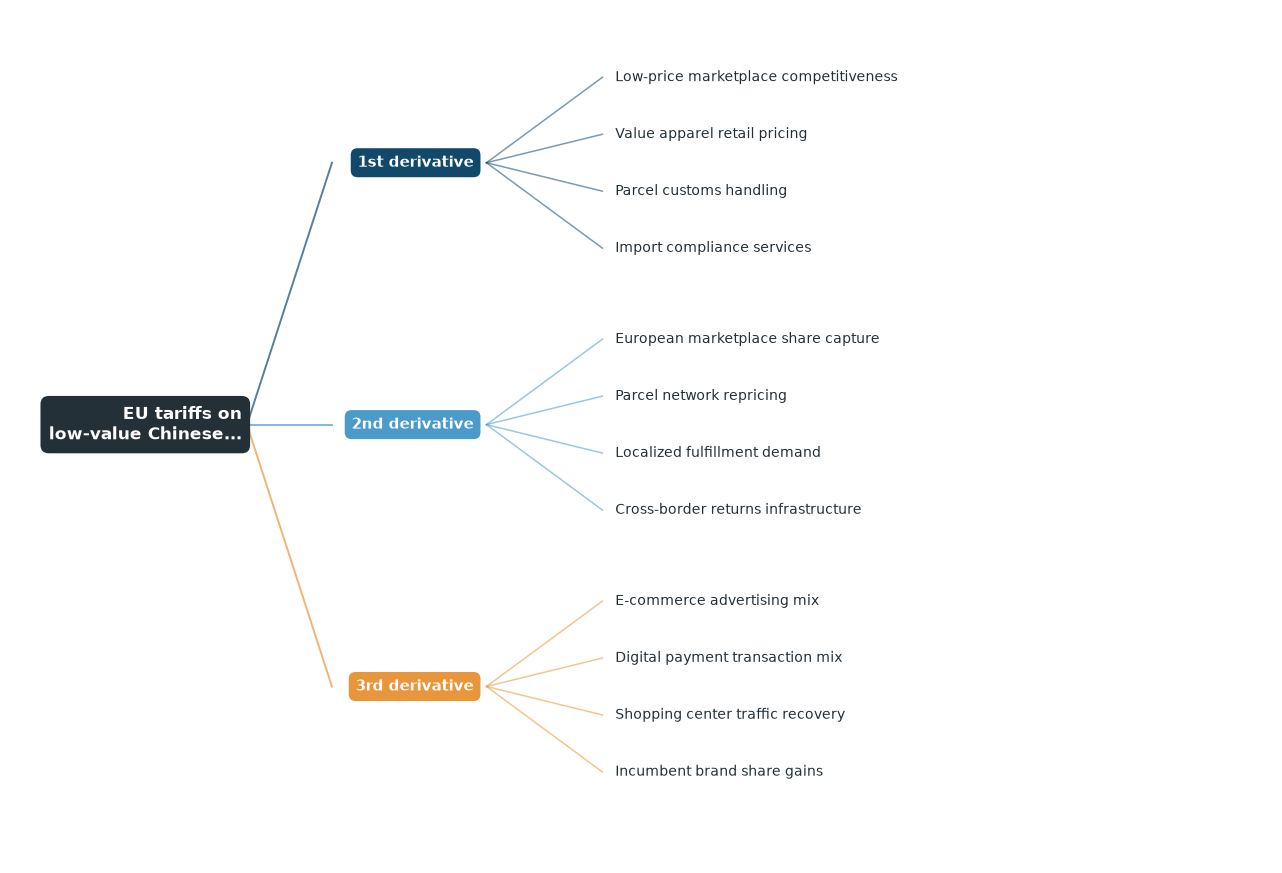

In [7]:
viz.plot_mindmap(root);

### The search behind each pathway

Each pathway is paired with the document-voice query used to find matching disclosure. These read like sentences a company would write about itself, which is what makes them effective against filings and transcripts.

In [8]:
hop_by_label = {
    leaf: branch for branch, leaves in preview.items() for leaf in leaves
}
pd.DataFrame(
    {
        "hop": [hop_by_label.get(label, "") for label in labels],
        "pathway": labels,
        "retrieval query": search_queries,
    }
).sort_values("hop").reset_index(drop=True)

,hop,pathway,retrieval query
0,1st derivative,Low-price marketplace competitiveness,"The company operates online marketplaces and reports gross merchandise value, conversion, and pricing for ..."
1,1st derivative,Value apparel retail pricing,"The company sells value-priced apparel and reports comparable sales, merchandise margins, and promotional ..."
2,1st derivative,Parcel customs handling,"The company processes low-value international parcels and provides customs clearance, duty collection, or ..."
3,1st derivative,Import compliance services,"The company provides customs brokerage, tariff classification, import documentation, and product complianc..."
4,2nd derivative,European marketplace share capture,"The company recruits third-party sellers and reports marketplace traffic, active buyers, and transaction v..."
5,2nd derivative,Parcel network repricing,"The company adjusts parcel surcharges, service levels, routing, or network capacity to manage internationa..."
6,2nd derivative,Localized fulfillment demand,"The company operates fulfillment centers and provides storage, pick-pack, and last-mile services for Europ..."
7,2nd derivative,Cross-border returns infrastructure,"The company manages e-commerce returns, product inspection, consolidation, refurbishment, and resale acros..."
8,3rd derivative,E-commerce advertising mix,"The company sells digital advertising and reports advertiser demand, cost per click, and spending by retai..."
9,3rd derivative,Digital payment transaction mix,"The company processes consumer and merchant payments and reports transaction volume, payment mix, and take..."


## Step 3 — Turn each pathway into a targeted search

Each pathway becomes its own search plan across all 150 companies and the full date window. Plans are built rather than executed blindly: the planner measures how much matching content exists per company and splits the work into batches sized to the available evidence, so heavily covered names do not crowd out thinly covered ones.

This is what keeps a third-hop pathway like discount retail from being drowned out by the volume of listed-retailer coverage.

In [9]:
context.ensure_plans_dir()
with quiet_output():
    plan_paths = screener.build_plans(
        labels=labels,
        search_queries=search_queries,
        company_ids=company_ids,
        plans_dir=context.plans_dir,
        start_date=START_DATE,
        end_date=END_DATE,
    )

print(f"Built {len(plan_paths)} search plans covering {len(company_ids)} companies each.")

Built 12 search plans covering 646 companies each.


## Step 4 — Retrieve the evidence

The plans now execute against filings, earnings transcripts, and premium news. Results are deduplicated across pathways, so a document that matches two pathways is stored once and counted once.

This is the longest step in the notebook, and the only one that touches the document corpus at scale.

In [10]:
with quiet_output():
    documents = screener.run_search(
        plans_dir=context.plans_dir,
        chunk_percentage=RETRIEVAL_DEPTH,
    )

context.ensure_results_dir()
with context.results_path.open("w", encoding="utf-8") as handle:
    json.dump(documents, handle, default=str)

retrieved_passages = sum(len(document.get("chunks", [])) for document in documents)
print(f"Retrieved {len(documents):,} unique documents")
print(f"Containing {retrieved_passages:,} candidate passages")

Retrieved 16,424 unique documents
Containing 26,111 candidate passages


## Step 5 — Classify every passage

Retrieval finds text that *looks* relevant; classification decides whether it genuinely evidences exposure. Each passage is assessed against the pathway set and assigned one pathway, a materiality rating, and a written rationale.

The classifier is deliberately strict about derivative hops. A passage that merely mentions China or tariffs is not enough to earn a second- or third-hop label — the text must evidence the actual mechanism, such as a customs process, a marketplace mix-shift, or a change in advertising and payments traffic. Anything ambiguous is discarded rather than counted, which is why the retained figure below is well short of the candidate pool.

In [11]:
sentences = screener.extract_sentences(documents, universe_df)

with quiet_output():
    classifications = screener.label_sentences(
        sentences=sentences,
        main_theme=MAIN_THEME,
        analyst_focus=ANALYST_FOCUS,
        labels=labels,
        profile=profile,
        taxonomy_root=root,
    )

labeled_df = screener.build_labeled_dataframe(sentences, classifications)
labeled_df.to_csv(context.labeled_sentences_path, index=False)
evidence_df = viz.attach_hop_column(labeled_df, root)

print(f"Passages assessed: {len(sentences):,}")
print(f"Confirmed exposure evidence: {len(evidence_df):,}")
print(f"Companies with confirmed exposure: {evidence_df['company_name'].nunique()}")

Passages assessed: 26,111
Confirmed exposure evidence: 68
Companies with confirmed exposure: 26


## Where the exposure sits

The first chart pair answers the structural question: how much evidence did each hop produce, and how many distinct companies does it touch?

The two panels usually tell different stories. First-hop exposure tends to be *deep* — a lot of evidence concentrated in a handful of listed retailers and parcel handlers. Later hops tend to be *broad* — less evidence per company, but spread across more of the portfolio. A wide third-hop bar on the right panel means the theme reaches further into the book than a China-e-commerce screen would suggest.

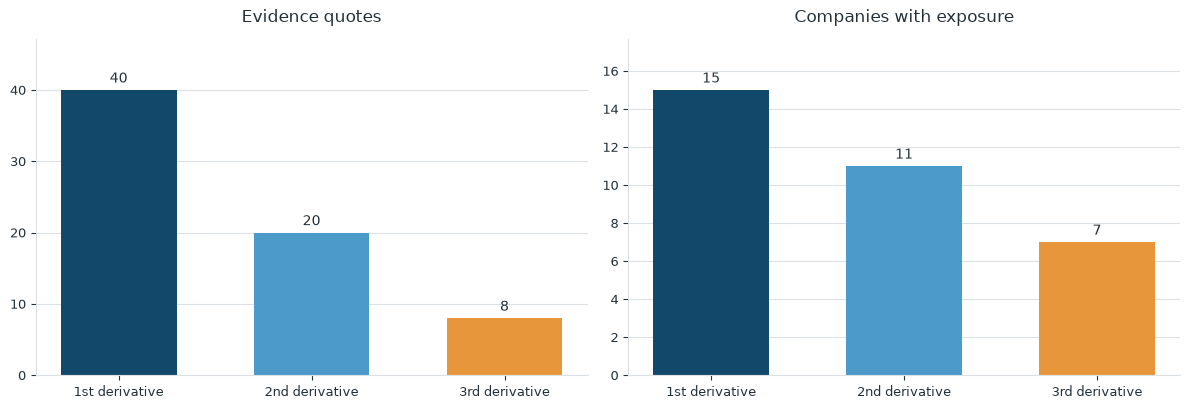

In [12]:
viz.plot_hop_coverage(evidence_df);

### Which pathways carry the evidence

Ranking pathways by evidence volume shows where the transmission chain is currently active. Bars are coloured by hop, so a highly ranked amber or mid-blue bar is a signal worth attention: it means an indirect mechanism is showing up in disclosure as strongly as the direct ones.

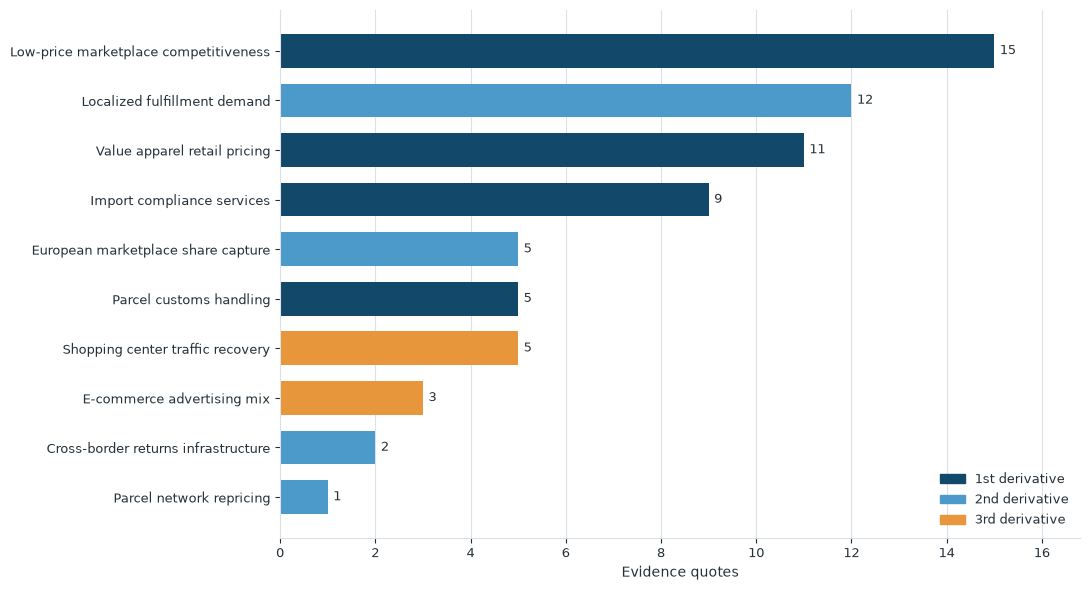

In [13]:
viz.plot_top_pathways(evidence_df);

### The most exposed companies

Each bar is one holding, segmented by the hops its evidence came from. The segmentation is the useful part: a bar that is entirely dark blue is a conventional retail or logistics exposure, while a bar with mid-blue or amber is a company whose sensitivity to the tariff runs through a less obvious channel.

Read this as the *consensus* view. Ranking by evidence volume favours direct exposure, because a listed retailer discusses Temu and Shein on every call while a payments or media name mentions parcel duties once a year. The indirect names are therefore almost absent here by construction — the next chart ranks them on their own terms.

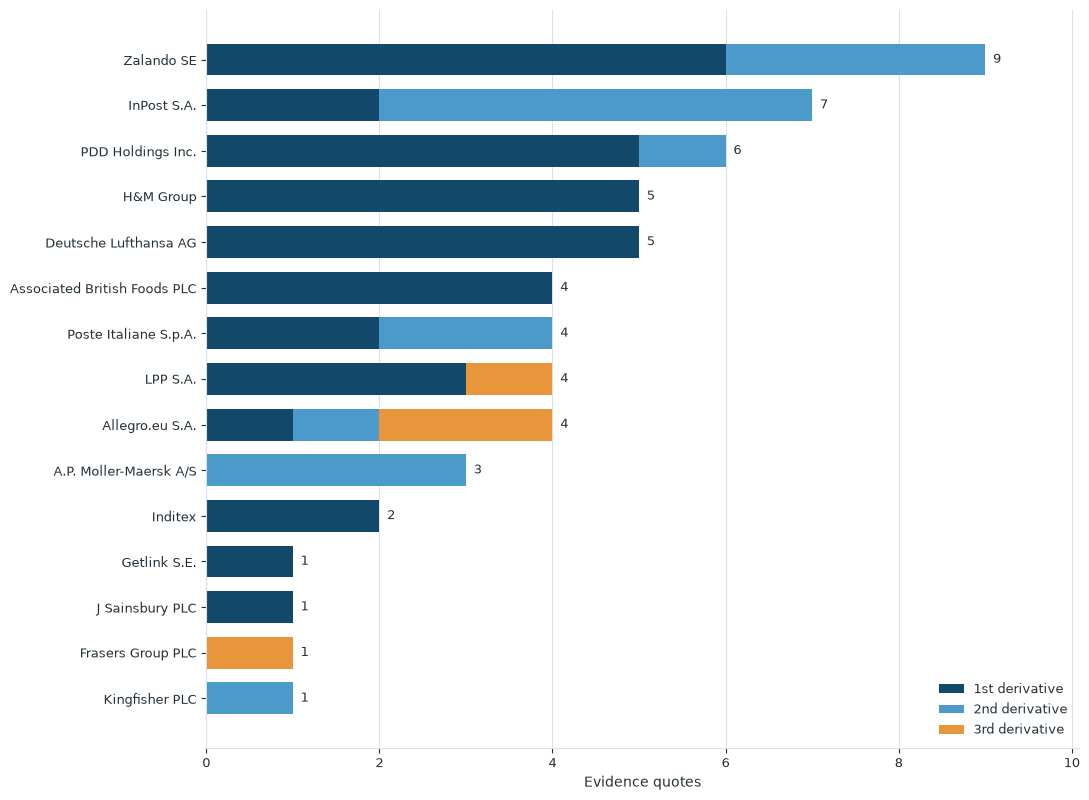

In [14]:
viz.plot_top_companies(evidence_df);

### Where the indirect exposure sits

This matrix drops direct exposure entirely and ranks companies on second- and third-hop evidence alone, so the later channels are no longer competing against retailer disclosure volume for a place in the chart.

The second-hop column is dominated by operating responses — customs, pricing, and mix. The third-hop column is a different list: media, payments, property, and consumer-finance names reached through traffic and mix-shift rather than through importing a parcel. Those are the holdings no China-e-commerce screen would return.

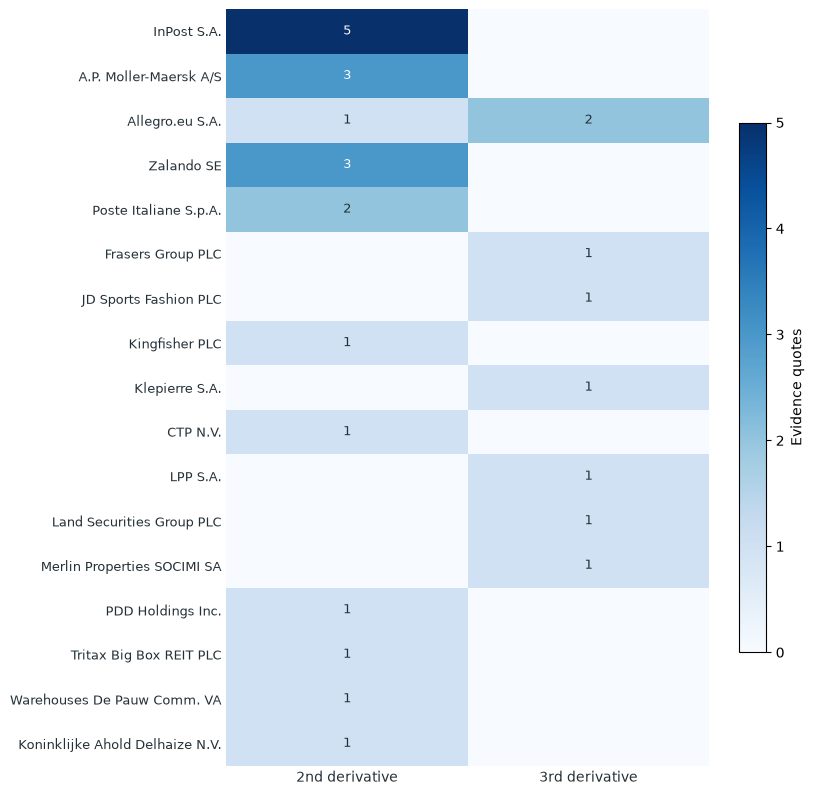

In [15]:
viz.plot_company_hop_matrix(evidence_df, hops=viz.INDIRECT_HOPS);

### How the story developed

Evidence plotted by publication month. Because filings and earnings calls cluster around reporting dates, some seasonality is expected. What matters is the *composition* over time: later hops appearing more prominently in recent months indicates the shock is still working its way through the chain rather than having fully played out.

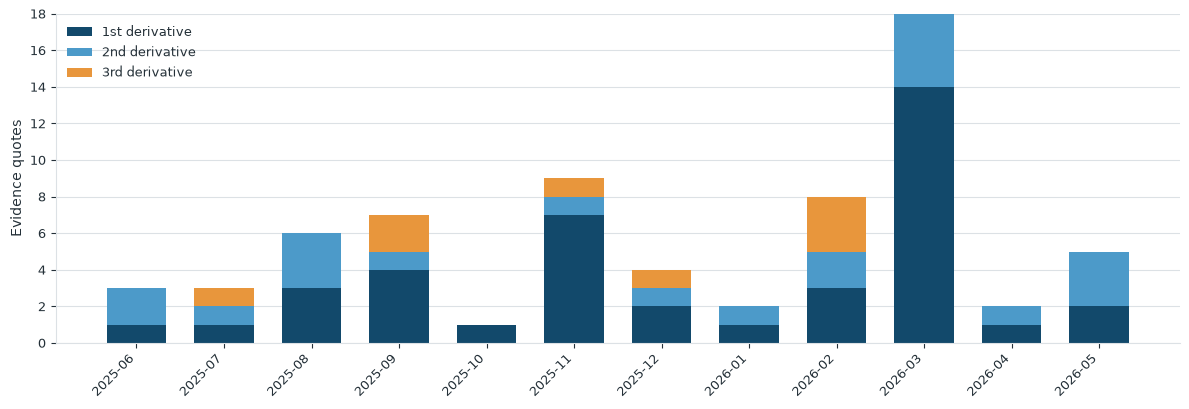

In [16]:
viz.plot_evidence_timeline(evidence_df);

## The non-obvious names

This is the core output of the screen. The table isolates companies whose exposure is **entirely** second- or third-hop — holdings with no direct retail-or-parcel linkage at all, which would not appear in any conventional China-e-commerce screen, yet have disclosed evidence of sensitivity to the theme.

Each row shows the pathway carrying the exposure and the opening words of the quote behind it, so the reasoning can be checked immediately. The complete quote, its source, and its date sit in the exported workbook and in `labeled_sentences.csv`.

In [17]:
FIRST_HOP = DERIVATIVE_BRANCH_LABELS[0]

hops_per_company = evidence_df.groupby("company_name")["hop"].agg(set)
indirect_only = [
    company for company, hops in hops_per_company.items() if hops and FIRST_HOP not in hops
]

indirect_df = (
    evidence_df[evidence_df["company_name"].isin(indirect_only)]
    .sort_values(["company_name", "hop"])
    .groupby("company_name")
    .first()
    .reset_index()
)
indirect_df["quotes"] = indirect_df["company_name"].map(
    evidence_df["company_name"].value_counts()
)
indirect_df["evidence"] = indirect_df["text"].map(preview_quote)

print(f"{len(indirect_only)} companies are exposed only through indirect channels.\n")
indirect_df.sort_values("quotes", ascending=False)[
    ["company_name", "hop", "label", "quotes", "evidence"]
].head(12).reset_index(drop=True)

11 companies are exposed only through indirect channels.



,company_name,hop,label,quotes,evidence
0,A.P. Moller-Maersk A/S,2nd derivative,Localized fulfillment demand,3,"For non-perishables, the solution is perhaps a little easier to manage. Stockpiling remains a …"
1,CTP N.V.,2nd derivative,Localized fulfillment demand,1,"Our core markets remain in Central and Eastern Europe (""CEE"") along- side our Western …"
2,Frasers Group PLC,3rd derivative,Shopping center traffic recovery,1,"The centre has seen sustained improvements in footfall, turnover and average spend, supported by …"
3,JD Sports Fashion PLC,3rd derivative,Shopping center traffic recovery,1,"Bullring is among the UK's best-performing and highly regarded retail and leisure destinations, recognised …"
4,Kingfisher PLC,2nd derivative,Localized fulfillment demand,1,"And turning now to the broader digital ecosystem we are building, and it starts …"
5,Klepierre S.A.,3rd derivative,Shopping center traffic recovery,1,"Our final client, shoppers, also widely favor our venues. Indeed, physical retail is a …"
6,Koninklijke Ahold Delhaize N.V.,2nd derivative,European marketplace share capture,1,"Talking about Amazon and bol, it's a competitive environment. We see every quarter something …"
7,Land Securities Group PLC,3rd derivative,Shopping center traffic recovery,1,"In retail, brands continue to focus on the best locations as these provide the …"
8,Merlin Properties SOCIMI SA,3rd derivative,Shopping center traffic recovery,1,Shopping Centres The retail sector continues to show a solid operating performance in Spain …
9,Tritax Big Box REIT PLC,2nd derivative,Localized fulfillment demand,1,[TRITAX BIG BOX logo] ecommerce contracts; Chinese retailers and associated 3PLs committing to multiple …


## Step 6 — Company narratives

Individual quotes are the audit trail; the investment case needs a synthesis. This step consolidates all confirmed evidence for each company into a single narrative explaining how that business is exposed to the theme.

These summaries are written only from evidence retained in the previous step, so they cannot introduce claims the documents do not support.

In [18]:
with quiet_output():
    summaries_df = screener.summarize_companies(
        merged_df=labeled_df,
        main_theme=MAIN_THEME,
        profile=profile,
    )
summaries_df.to_csv(context.company_summaries_path, index=False)

screener_df = screener.build_screener_dataframe(labeled_df, summaries_df)
screener_df.to_csv(context.screener_results_path, index=False)

print(f"Wrote narratives for {len(summaries_df)} companies.")

Wrote narratives for 26 companies.


### Narratives for the most exposed holdings

The five companies with the most supporting evidence, with their exposure channels noted above each narrative.

In [19]:
top_companies = evidence_df["company_name"].value_counts().head(5)
summary_lookup = dict(zip(summaries_df["company_name"], summaries_df["summary"]))

for company, quote_count in top_companies.items():
    company_hops = sorted(set(evidence_df.loc[evidence_df["company_name"] == company, "hop"].dropna()))
    print(f"{company}  —  {quote_count} quotes  —  {', '.join(company_hops)}")
    narrative = summary_lookup.get(company, "No narrative generated.")
    print(textwrap.fill(str(narrative), width=100, initial_indent="  ", subsequent_indent="  "))
    print()

Zalando SE  —  9 quotes  —  1st derivative, 2nd derivative
  Zalando faces medium exposure to intensified low-price competition in European online fashion and
  general merchandise from Shein, Temu and AliExpress, potentially pressuring marketplace demand,
  pricing and margins while encouraging strategic responses such as the About You acquisition and
  warehouse-sharing plans. Its European marketplace also provides potential share-capture and
  revenue opportunities as brands expand online, including M&S, while ZEOS’s mainland-European
  fulfillment services could benefit from tariff- or compliance-driven shifts toward localized
  inventory and fulfillment. At the same time, EU-based inventory requirements, customs formalities
  and importer obligations for non-EEA suppliers create operational and documentation burdens,
  including product and technical compliance requirements, although the motivations do not quantify
  any tariff-specific financial impact.

InPost S.A.  —  7 quotes 

## Step 7 — The deliverable pack

The run is exported in two formats. The Excel workbook is the working document for an analyst: labelled evidence, company narratives, a company-by-pathway scoring grid, and the taxonomy itself, each on its own sheet. The JSON report carries the same content in the schema used by the Bigdata.com visualisation app.

Both sit alongside the intermediate artefacts in the run directory, so any number in this notebook can be traced back to the document it came from.

In [20]:
report = screener.build_report_json(screener_df, root, universe_df, MODE)
with context.report_json_path.open("w", encoding="utf-8") as handle:
    json.dump(report, handle, indent=2, default=str)

excel_path = screener.export_excel(
    screener_df=screener_df,
    company_summaries_df=summaries_df,
    root=root,
    path=context.report_excel_path,
)

for artefact in sorted(context.run_dir.glob("*")):
    if artefact.is_file():
        print(f"{artefact.name:<28} {artefact.stat().st_size / 1024:>8.1f} KB")

company_summaries.csv            15.1 KB
config.json                       0.7 KB
grounding.json                   26.6 KB
labeled_sentences.csv           148.8 KB
report.json                     197.0 KB
report.xlsx                      76.6 KB
screener_results.csv            194.7 KB
search_queries.txt                1.5 KB
taxonomy_tree.json                6.0 KB
themes.txt                        0.4 KB


### The screen output

The ranked screen, which is the sheet an analyst works from. Each row carries the company, the number of confirmed evidence quotes behind it, the derivative channels that evidence arrived through, and the pathway contributing most of it.

The workbook expands this into the full grid — every company scored against every individual pathway — alongside the underlying quotes.

In [21]:
scoring_df = screener.build_company_scoring_df(screener_df)

screen = (
    evidence_df.groupby("company_name")
    .agg(
        quotes=("sentence_id", "count"),
        channels=("hop", lambda hops: ", ".join(sorted(set(hops.dropna())))),
        lead_pathway=("label", lambda labels: labels.value_counts().index[0]),
    )
    .sort_values("quotes", ascending=False)
    .reset_index()
)

print(f"Full grid in the workbook: {len(scoring_df)} companies x {len(labels)} pathways\n")
screen.head(15)

Full grid in the workbook: 26 companies x 12 pathways



,company_name,quotes,channels,lead_pathway
0,Zalando SE,9,"1st derivative, 2nd derivative",Low-price marketplace competitiveness
1,InPost S.A.,7,"1st derivative, 2nd derivative",Localized fulfillment demand
2,PDD Holdings Inc.,6,"1st derivative, 2nd derivative",Low-price marketplace competitiveness
3,H&M Group,5,1st derivative,Value apparel retail pricing
4,Deutsche Lufthansa AG,5,1st derivative,Import compliance services
5,Associated British Foods PLC,4,1st derivative,Value apparel retail pricing
6,Poste Italiane S.p.A.,4,"1st derivative, 2nd derivative",Localized fulfillment demand
7,LPP S.A.,4,"1st derivative, 3rd derivative",Low-price marketplace competitiveness
8,Allegro.eu S.A.,4,"1st derivative, 2nd derivative, 3rd derivative",E-commerce advertising mix
9,A.P. Moller-Maersk A/S,3,2nd derivative,Localized fulfillment demand


## Reusing this analysis

The screen is theme-agnostic. Changing `MAIN_THEME` and `ANALYST_FOCUS` at the top and re-running produces the same three-hop treatment of any shock — a tariff regime, a rate cut, a regulatory change — against any universe supplied as a CSV of entity identifiers.

The identical workflow is available from the command line, which is the better route for scheduled or batch runs:

```bash
uv run python -m src.cli run-all \\
  --run-name eu_parcel_tariff_derivatives \\
  --taxonomy-style derivatives \\
  --ground-with-bigdata \\
  --main-theme "EU tariffs on low-value Chinese e-commerce parcels" \\
  --analyst-focus "Hidden 1st/2nd/3rd derivative exposures in European mid/large caps" \\
  --universe europe_ml_caps.csv
```

Because this notebook writes to the same run directory, a session started here can be continued from the command line, and vice versa.